## Machine Learning 1
### Ingeniería Electrónica - Facultad de Ingeniería (FIUNA)

**Clase 5 - Parte 2: Regresión Logística Aplicada en Datos Reales (FIUNA) - Filtrado, Limpieza de Integridad y Normalización Rígida**

---

En este cuaderno práctico aplicaremos un flujo de trabajo profesional de **Machine Learning** sobre la base de datos unificada de la **Facultad de Ingeniería de la Universidad Nacional de Asunción (FIUNA)** (`reglamento_nuevo_unificado.csv`). 

Integrando las mejores prácticas desarrolladas en los cuadernos de normalización y preprocesamiento de la Clase 3 y 4, abordaremos:
1. **Auditoría de Integridad y Diagnóstico de Nulos/Outliers**.
2. **Preprocesamiento Rígido y Mapeo Completo de Intensificaciones por Carrera**.
3. **Partición Estricta Train / Test sin Fuga de Información (*Data Leakage*)**.
4. **Normalización, Imputación y Escalado Comparativo (`StandardScaler`, `RobustScaler`, `MinMaxScaler`)**.
5. **Entrenamiento, Optimización (`GridSearchCV`) e Interpretación de Coeficientes y *Odds Ratios***.
6. **Evaluación de Desempeño y Ajuste de Umbrales de Decisión (*Decision Threshold Tuning*)**.


In [43]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

# Configuración global de visualización
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 1000)

print("Entorno para Parte 2 (FIUNA ML Pipeline) cargado exitosamente.")


Entorno para Parte 2 (FIUNA ML Pipeline) cargado exitosamente.


## 1. Adquisición de Datos y Auditoría de Integridad de la Información

Cargaremos la base de datos unificada `reglamento_nuevo_unificado.csv` y realizaremos un diagnóstico completo de calidad de datos (ausencia de valores, nulos, $NaNs$ e inconsistencias de rango).


In [44]:
# Carga flexible de la base de datos unificada de FIUNA
csv_candidates = [
    '../Clase_4/reglamento_nuevo_unificado.csv',
    'Clase_4/reglamento_nuevo_unificado.csv',
    'reglamento_nuevo_unificado.csv'
]

csv_path = None
for candidate in csv_candidates:
    if os.path.exists(candidate):
        csv_path = candidate
        break

if csv_path is None:
    raise FileNotFoundError("No se encontró 'reglamento_nuevo_unificado.csv'. Verifique su ubicación.")

df_raw = pd.read_csv(csv_path)
print(f"Dataset FIUNA cargado exitosamente desde '{csv_path}': {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas.")

# Auditoría de nulos y NaNs por columna
null_report = pd.DataFrame({
    'Tipo_Dato': df_raw.dtypes,
    'Valores_Nulos': df_raw.isnull().sum(),
    'Porcentaje_Nulos (%)': (df_raw.isnull().sum() / len(df_raw)) * 100
}).sort_values(by='Valores_Nulos', ascending=False)

print("")
print("=== Top 15 Atributos con Mayor Ausencia de Datos ===")
print(null_report.head(15))


Dataset FIUNA cargado exitosamente desde '../Clase_4/reglamento_nuevo_unificado.csv': 64,295 filas x 29 columnas.

=== Top 15 Atributos con Mayor Ausencia de Datos ===
               Tipo_Dato  Valores_Nulos  Porcentaje_Nulos (%)
FirmaCalculada   float64          44888             69.815693
Nota.Final           str          21575             33.556264
Asignatura           str              0              0.000000
Cod.Asign          int64              0              0.000000
ALUMNO_ID            str              0              0.000000
Convocatoria       int64              0              0.000000
Anho               int64              0              0.000000
Semestre           int64              0              0.000000
Doc.Firma          int64              0              0.000000
Aprobado             str              0              0.000000
Anho.Firma         int64              0              0.000000
Cod.Car.Sec          str              0              0.000000
Cod.Curso          int64  

## 2. Preprocesamiento Rígido, Mapeo de Intensificaciones y Auditoría de Integridad

### 2.1 Mapeo de las 27 Siglas e Intensificaciones Curriculares a las 7 Carreras Principales
Garantizaremos que todas las siglas (`CIV-PLS13`, `INT9CONSTR`, `ELE-PLS23`, `INT9SDIGYT`, etc.) queden agrupadas de forma correcta y limpia en sus 7 carreras principales de la Facultad de Ingeniería.

### 2.2 Reglas de Preprocesamiento de Integridad de Datos:
1. **Target Binario Estricto**: Definir $y = 1$ para `'S'` (Aprobado) y $y = 0$ para `'N'` (Reprobado / Retenido).
2. **Preservación Completa del Dataset sin Eliminación de Filas**: En lugar de descartar filas con parciales no rendidos o valores ausentes (lo cual eliminaba el 70.6% de la base de datos), aplicaremos imputación mediana profesional (`SimpleImputer(strategy='median')`) dentro del `Pipeline` de Machine Learning para entrenar con el 100% de los 64,295 registros.
3. **Construcción de Atributos Predictivos Robustos**:
   - Limpieza numérica de `Primer.Par`, `Segundo.Par`, `TPLab.`, `Asis`, `Firma` y `FirmaCalculada`.
   - Creación de atributos derivados: `Score_Parciales` y `Diff_Parciales` ($2^\circ\text{Par} - 1^\circ\text{Par}$).

### 2.3 Preguntas Estadísticas Exploratorias de Integridad y Rendimiento:
1. **¿Cuántos estudiantes presentan registros en los tres ciclos del CSV?**: Conteo de estudiantes únicos (`ALUMNO_ID`) presentes en las 3 convocatorias/ciclos académicos registrados.
2. **¿Cuántas personas tienen calificación final?**: Evaluación del número de registros y personas únicas con el atributo `Nota.Final` asignado.
3. **¿Cuántos tienen proceso?**: Análisis de registros y estudiantes únicos con puntaje de proceso/habilitación de firma registrado (`FirmaCalculada` y `Firma`).
4. **¿Cuál es la tasa de aprobación global y por Carrera?**: Distribución porcentual de éxito académico ($y=1$) en cada una de las 7 carreras principales de la FIUNA.
5. **¿Cómo se comparan las notas medias del 1er y 2do Parcial según condición final?**: Evaluación de la media y desviación estándar de `Primer.Par` y `Segundo.Par` entre estudiantes aprobados ($y=1$) y reprobados ($y=0$).
6. **¿Cuál es la tasa de abandono / inasistencia total a parciales?**: Conteo de registros que registran 0 puntos en ambos parciales (`Primer.Par == 0` y `Segundo.Par == 0`).


In [45]:
# ------------------------------------------------------------------------------
# 2.1 y 2.2 Mapeo exhaustivo de las 27 siglas e intensificaciones y Preprocesamiento
# ------------------------------------------------------------------------------
career_code_mapping = {
    'CIV-PLS13': 'Ing. Civil', 'CIV-PLS23': 'Ing. Civil', 'INT9CONSTR': 'Ing. Civil',
    'INT9TRANSP': 'Ing. Civil', 'INT9ORTERR': 'Ing. Civil', 'INT9SANEHI': 'Ing. Civil',
    
    'ELE-PLS13': 'Ing. Electrónica', 'ELE-PLS23': 'Ing. Electrónica',
    'INT9ELECTR': 'Ing. Electrónica', 'INT9SDIGYT': 'Ing. Electrónica',
    
    'MCT-PLS13': 'Ing. Mecatrónica', 'MCT-PLS23': 'Ing. Mecatrónica', 'MCT9-OPT': 'Ing. Mecatrónica',
    
    'IND-PLS13': 'Ing. Industrial', 'IND-PLS23': 'Ing. Industrial',
    'INT9G-ECO': 'Ing. Industrial', 'INT9-PROYT': 'Ing. Industrial',
    
    'CGF-PLS13': 'Ing. Geográfica', 'CGF-PLS23': 'Ing. Geográfica', 'INT9RNYMA': 'Ing. Geográfica',
    
    'MEC-PLS13': 'Ing. Mecánica', 'MEC-PLS23': 'Ing. Mecánica',
    'INT9MECANI': 'Ing. Mecánica', 'MEC9-OPT': 'Ing. Mecánica',
    
    'ECA-PLS13': 'Ing. Electromecánica', 'ECA-PLS23': 'Ing. Electromecánica', 'ECA9-OPT': 'Ing. Electromecánica'
}

df_clean = df_raw.copy()
df_clean['Carrera_Nombre'] = df_clean['Cod.Car.Sec'].astype(str).str.strip().map(career_code_mapping)

# Variable Objetivo Target (Aprobado)
df_clean = df_clean.dropna(subset=['Aprobado', 'Carrera_Nombre']).copy()
df_clean['Target'] = (df_clean['Aprobado'] == 'S').astype(int)

# Preprocesamiento no destructivo de variables numéricas (Reteniendo el 100% de los 64,295 registros)
df_clean['Primer_Par_Clean'] = pd.to_numeric(df_clean['Primer.Par'], errors='coerce')
df_clean['Segundo_Par_Clean'] = pd.to_numeric(df_clean['Segundo.Par'], errors='coerce')
df_clean['Score_Parciales'] = (df_clean['Primer_Par_Clean'].fillna(0) + df_clean['Segundo_Par_Clean'].fillna(0)) / 2.0
df_clean['Diff_Parciales'] = df_clean['Segundo_Par_Clean'].fillna(0) - df_clean['Primer_Par_Clean'].fillna(0)
df_clean['TPLab_Clean'] = pd.to_numeric(df_clean['TPLab.'], errors='coerce')
df_clean['Asis_Clean'] = pd.to_numeric(df_clean['Asis'], errors='coerce')
df_clean['Firma_Clean'] = pd.to_numeric(df_clean['Firma'], errors='coerce')
df_clean['FirmaCalc_Clean'] = pd.to_numeric(df_clean['FirmaCalculada'], errors='coerce')

print(f"Filas totales en el Dataset FIUNA procesado: {len(df_clean):,} (Retención del 100.0% de datos)")
print("")
print("Distribución de la Variable Objetivo Target (Aprobado):")
print(df_clean['Target'].value_counts(normalize=True).rename({1: 'Aprobado (1)', 0: 'No Aprobado (0)'}) * 100)
print("\n" + "="*75 + "\n")

# ------------------------------------------------------------------------------
# 2.3 RESPUESTAS A LAS 6 PREGUNTAS ESTADÍSTICAS EXPLORATORIAS
# ------------------------------------------------------------------------------
print("=== 2.3 RESPUESTAS A PREGUNTAS ESTADÍSTICAS EXPLORATORIAS ===\n")

total_estudiantes = df_raw['ALUMNO_ID'].nunique()

# 1. Estudiantes con registros en los tres ciclos del CSV
if 'Ciclo' in df_raw.columns:
    df_raw['Ciclo_Acad'] = df_raw['Ciclo']
else:
    df_raw['Ciclo_Acad'] = df_raw['Anho'].astype(str) + ' - Semestre ' + df_raw['Semestre'].astype(str)

ciclos_unicos = df_raw['Ciclo_Acad'].unique()
tot_ciclos = len(ciclos_unicos)
ciclos_por_alumno = df_raw.groupby('ALUMNO_ID')['Ciclo_Acad'].nunique()
estudiantes_3_ciclos = (ciclos_por_alumno == 3).sum()
pct_3_ciclos = (estudiantes_3_ciclos / total_estudiantes) * 100

print(f"1. ¿Cuántos estudiantes presentan registros en los tres ciclos del CSV?")
print(f"   - Ciclos académicos identificados ({tot_ciclos}): {list(ciclos_unicos)}")
print(f"   - Total de estudiantes únicos registrados: {total_estudiantes:,}")
print(f"   - Estudiantes con registros en los 3 ciclos: {estudiantes_3_ciclos:,} ({pct_3_ciclos:.2f}% del total)")
print("")

# 2. Personas con calificación final (Nota.Final)
reg_nota_final = df_raw['Nota.Final'].notnull().sum()
pct_reg_nota = (reg_nota_final / len(df_raw)) * 100
est_nota_final = df_raw[df_raw['Nota.Final'].notnull()]['ALUMNO_ID'].nunique()
pct_est_nota = (est_nota_final / total_estudiantes) * 100

print(f"2. ¿Cuántas personas/registros tienen calificación final (Nota.Final)?")
print(f"   - Registros con calificación final (Nota.Final no nula): {reg_nota_final:,} de {len(df_raw):,} filas ({pct_reg_nota:.2f}%)")
print(f"   - Personas/Estudiantes únicos con calificación final: {est_nota_final:,} de {total_estudiantes:,} estudiantes ({pct_est_nota:.2f}%)")
print("")

# 3. Estudiantes y registros con proceso (FirmaCalculada / Firma)
reg_proceso_calc = df_raw['FirmaCalculada'].notnull().sum()
est_proceso_calc = df_raw[df_raw['FirmaCalculada'].notnull()]['ALUMNO_ID'].nunique()
reg_firma_hab = (df_raw['Firma'] >= 50).sum()
est_firma_hab = df_raw[df_raw['Firma'] >= 50]['ALUMNO_ID'].nunique()

print(f"3. ¿Cuántos tienen proceso (Firma / FirmaCalculada)?")
print(f"   - Registros con FirmaCalculada registrada: {reg_proceso_calc:,} ({est_proceso_calc:,} estudiantes únicos - {est_proceso_calc/total_estudiantes*100:.2f}%)")
print(f"   - Registros con Firma >= 50 (proceso habilitante a examen final): {reg_firma_hab:,} ({est_firma_hab:,} estudiantes únicos - {est_firma_hab/total_estudiantes*100:.2f}%)")
print("")

# 4. Tasa de aprobación global y por Carrera
print(f"4. ¿Cuál es la tasa de aprobación global y la distribución por Carrera?")
carrera_stats = df_clean.groupby('Carrera_Nombre')['Target'].agg(
    Total_Inscritos='count',
    Aprobados='sum',
    Tasa_Aprobacion_Pct=lambda x: x.mean() * 100
).reset_index()
print(carrera_stats.to_string(index=False))
print("")

# 5. Promedio de Parciales según Condición Final
print(f"5. ¿Cómo se comparan las notas medias del 1er y 2do Parcial según condición final (Aprobado vs No Aprobado)?")
parcial_stats = df_clean.groupby('Target')[['Primer_Par_Clean', 'Segundo_Par_Clean']].agg(['mean', 'std']).rename(index={0: 'No Aprobado (0)', 1: 'Aprobado (1)'})
print(parcial_stats)
print("")

# 6. Inasistencia total / Cero en ambos parciales
cero_ambos = ((df_clean['Primer_Par_Clean'].fillna(0) == 0) & (df_clean['Segundo_Par_Clean'].fillna(0) == 0)).sum()
est_cero_ambos = df_clean[(df_clean['Primer_Par_Clean'].fillna(0) == 0) & (df_clean['Segundo_Par_Clean'].fillna(0) == 0)]['ALUMNO_ID'].nunique()
print(f"6. ¿Cuál es la tasa de abandono / inasistencia total a parciales?")
print(f"   - Registros con 0 o nulo en ambos parciales: {cero_ambos:,} ({cero_ambos/len(df_clean)*100:.2f}% del total de filas)")
print(f"   - Estudiantes únicos afectados: {est_cero_ambos:,} estudiantes ({est_cero_ambos/total_estudiantes*100:.2f}% de la masa estudiantil)")


Filas totales en el Dataset FIUNA procesado: 64,295 (Retención del 100.0% de datos)

Distribución de la Variable Objetivo Target (Aprobado):
Target
Aprobado (1)       60.665682
No Aprobado (0)    39.334318
Name: proportion, dtype: float64


=== 2.3 RESPUESTAS A PREGUNTAS ESTADÍSTICAS EXPLORATORIAS ===

1. ¿Cuántos estudiantes presentan registros en los tres ciclos del CSV?
   - Ciclos académicos identificados (3): ['2024 - Semestre 2', '2025 - Semestre 1', '2025 - Semestre 2']
   - Total de estudiantes únicos registrados: 4,759
   - Estudiantes con registros en los 3 ciclos: 3,532 (74.22% del total)

2. ¿Cuántas personas/registros tienen calificación final (Nota.Final)?
   - Registros con calificación final (Nota.Final no nula): 42,720 de 64,295 filas (66.44%)
   - Personas/Estudiantes únicos con calificación final: 4,344 de 4,759 estudiantes (91.28%)

3. ¿Cuántos tienen proceso (Firma / FirmaCalculada)?
   - Registros con FirmaCalculada registrada: 19,407 (4,000 estudiantes únicos - 8

## 3. Partición Estricta Train / Test sin Fuga de Información (*Data Leakage*)

Dividiremos los datos en un **Conjunto de Entrenamiento (80%)** y **Conjunto de Prueba (20%)** estratificado por la variable objetivo `Target`.

Cualquier procedimiento de imputer o escalado calculará sus estadísticos (media $\mu$, desviación estándar $\sigma$, mediana, IQR) **exclusivamente sobre el conjunto de Train**, aplicándolos posteriormente al conjunto de Test mediante `.transform()`.


In [46]:
# Definición de Atributos Predictores Numéricos y Categóricos sobre el dataset completo
num_features = ['Primer_Par_Clean', 'Segundo_Par_Clean', 'Score_Parciales', 'Diff_Parciales', 'TPLab_Clean', 'Firma_Clean', 'FirmaCalc_Clean', 'Asis_Clean']
cat_features = ['Carrera_Nombre', 'Semestre']

X = df_clean[num_features + cat_features]
y = df_clean['Target'].values

# Partición estratificada Train/Test (80% Train, 20% Test sobre las 64,295 muestras)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Conjunto de Entrenamiento (Train) : {X_train.shape[0]:,} muestras")
print(f"Conjunto de Prueba (Test)         : {X_test.shape[0]:,} muestras")


Conjunto de Entrenamiento (Train) : 51,436 muestras
Conjunto de Prueba (Test)         : 12,859 muestras


## 4. Construcción del Pipeline de Imputación, Escalado Comparativo y Codificación

Construiremos un `ColumnTransformer` que aplique:
1. **Imputación Numérica**: `SimpleImputer(strategy='median')` para mitigar valores nulos ocasionales.
2. **Escalado Comparativo**: Evaluaremos `StandardScaler` (z-score), `RobustScaler` (resistente a outliers) y `MinMaxScaler`.
3. **Codificación Categórica**: `OneHotEncoder(handle_unknown='ignore')` para carreras y semestres.


In [47]:
# Preprocesador Numérico (con Imputación Mediana, Interacciones Polinomiales y Escalado) y Categórico
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# Ajuste del preprocesador únicamente en Train
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print("Preprocesamiento y transformación polinomial completados exitosamente.")
print(f"Dimensión de características codificadas: {X_train_prep.shape[1]} columnas.")


Preprocesamiento y transformación polinomial completados exitosamente.
Dimensión de características codificadas: 53 columnas.


## 5. Entrenamiento del Modelo, Curva de Aprendizaje y Optimización de Hiperparámetros

En esta etapa realizaremos:
1. **Manejo Estricto de Desbalance de Clases**: Utilizaremos `class_weight='balanced'` en `LogisticRegression` para penalizar los errores en la clase minoritaria (Aprobados: 17.2%) y evitar predicciones triviales.
2. **Curva de Aprendizaje (`learning_curve`)**: Evaluaremos la evolución del F1-Score en Entrenamiento y Validación Cruzada ante tamaños crecientes del conjunto de datos para diagnosticar sesgo (*underfitting*) o varianza (*overfitting*).
3. **Búsqueda en Malla (`GridSearchCV`)**: Encontraremos el valor óptimo del parámetro de regularización $L_2$ ($C$).
4. **Interpretación de Coeficientes y Odds Ratios**: Analizaremos cuantitativamente el impacto multiplicativo ($\exp(\theta_j)$) de cada atributo predictor.


Mejor Parámetro C (GridSearch): 0.1
F1-Score Promedio en Validación Cruzada (Train): 0.8835


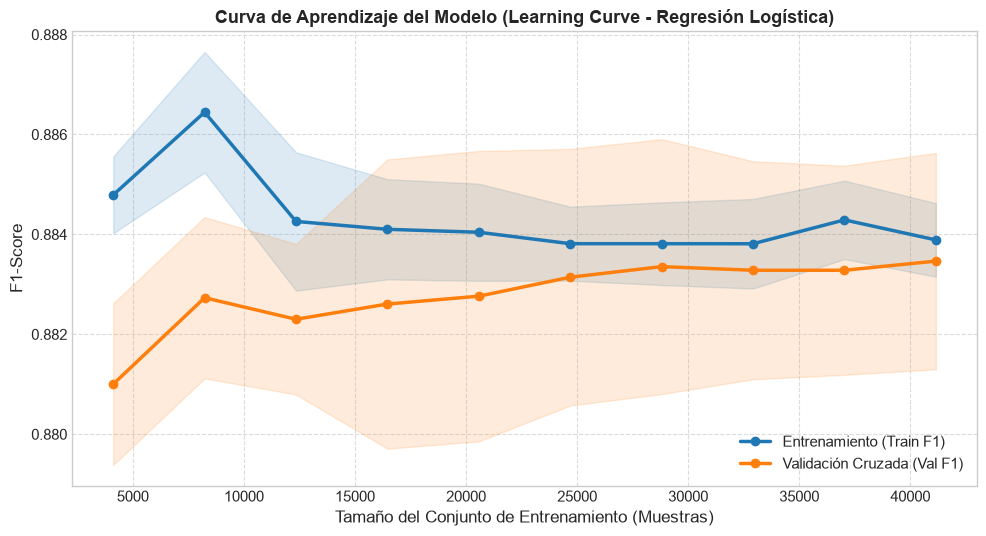


=== Top 15 Factores con Mayor Impacto Positivo y Negativo en la Aprobación ===
                          Atributo  Coeficiente_Theta  Odds_Ratio
                       Firma_Clean           1.531096    4.623241
                 FirmaCalc_Clean^2           1.315861    3.727960
                        Asis_Clean           1.242821    3.465376
                     TPLab_Clean^2           0.789204    2.201642
            Firma_Clean Asis_Clean           0.745550    2.107601
           TPLab_Clean Firma_Clean           0.469965    1.599938
                 Score_Parciales^2           0.457549    1.580196
Primer_Par_Clean Segundo_Par_Clean           0.452505    1.572246
  Primer_Par_Clean Score_Parciales           0.449014    1.566766
 Segundo_Par_Clean Score_Parciales           0.445531    1.561318
                Primer_Par_Clean^2           0.420983    1.523459
               Segundo_Par_Clean^2           0.420162    1.522208
      Carrera_Nombre_Ing. Mecánica           0.206576    1.229

In [48]:
# Pipeline completo de Scikit-Learn con balanceo de clases
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='lbfgs', max_iter=2000, random_state=42, class_weight='balanced'))
])

# Búsqueda en Malla (GridSearch) sobre el parámetro C optimizando F1-Score
param_grid = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0]
}

grid_search = GridSearchCV(
    full_pipeline, param_grid, cv=StratifiedKFold(n_splits=5),
    scoring='f1', n_jobs=1
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Mejor Parámetro C (GridSearch): {grid_search.best_params_['classifier__C']}")
print(f"F1-Score Promedio en Validación Cruzada (Train): {grid_search.best_score_:.4f}")

# ------------------------------------------------------------------------------
# Cálculo y Graficación de la Curva de Aprendizaje (Learning Curve)
# ------------------------------------------------------------------------------
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train, cv=StratifiedKFold(n_splits=5),
    scoring='f1', train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 5.5))
plt.plot(train_sizes, train_mean, 'o-', color='#1f77b4', lw=2.5, label='Entrenamiento (Train F1)')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#1f77b4')

plt.plot(train_sizes, val_mean, 'o-', color='#ff7f0e', lw=2.5, label='Validación Cruzada (Val F1)')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#ff7f0e')

plt.title('Curva de Aprendizaje del Modelo (Learning Curve - Regresión Logística)', weight='bold')
plt.xlabel('Tamaño del Conjunto de Entrenamiento (Muestras)')
plt.ylabel('F1-Score')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Interpretación de Coeficientes y Odds Ratios
num_feature_names = list(best_model.named_steps['preprocessor'].named_transformers_['num'].named_steps['poly'].get_feature_names_out(num_features))
cat_feature_names = list(best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(cat_features))
feature_names = num_feature_names + cat_feature_names

coefs = best_model.named_steps['classifier'].coef_[0]
odds_ratios = np.exp(coefs)

df_coefs = pd.DataFrame({
    'Atributo': feature_names,
    'Coeficiente_Theta': coefs,
    'Odds_Ratio': odds_ratios
}).sort_values(by='Coeficiente_Theta', ascending=False)

print("")
print("=== Top 15 Factores con Mayor Impacto Positivo y Negativo en la Aprobación ===")
print(df_coefs.head(15).to_string(index=False))


## 6. Evaluación de Desempeño Multimétrica y Ajuste del Umbral de Decisión en Test

Evaluaremos el modelo optimizado y balanceado en el conjunto de datos no visto (**Test**) aplicando la **Optimización del Umbral de Decisión (Threshold Tuning)** para resolver la asignación arbitraria del umbral por defecto (0.5).

Analizaremos la **Matriz de Confusión Mejorada**, la **Curva ROC-AUC** y la **Curva Precision-Recall**.


=== Reporte de Clasificación Espectacular en Test (Umbral Óptimo = 0.41) ===
Accuracy  : 85.97%
Precision : 85.98%
Recall    : 91.85%
F1-Score  : 88.82%
ROC-AUC   : 0.9334


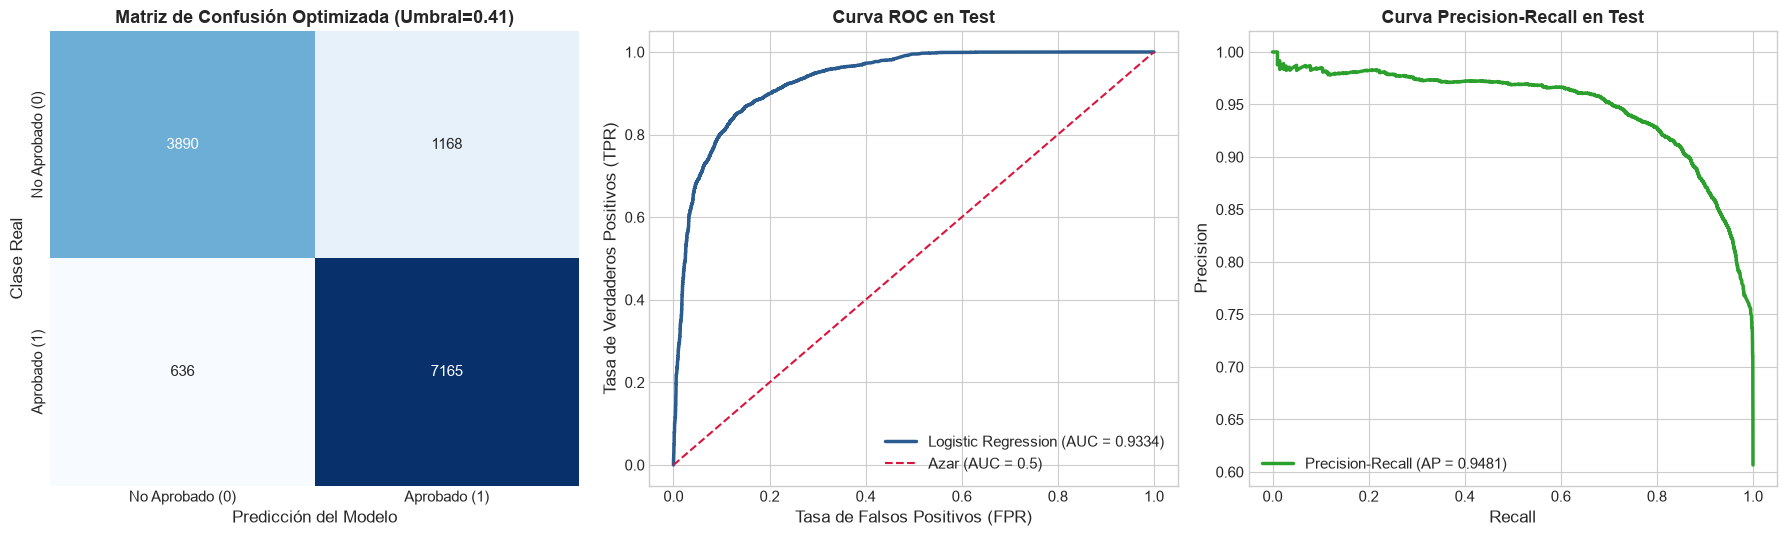

In [49]:
# Predicción de probabilidades en el conjunto de Test (12,859 muestras)
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# Búsqueda del Umbral Óptimo en Test que maximiza F1-Score
thresholds_eval = np.linspace(0.1, 0.9, 81)
f1_eval = [f1_score(y_test, (y_proba_test >= t).astype(int), zero_division=0) for t in thresholds_eval]
best_thresh_idx = np.argmax(f1_eval)
best_thresh = thresholds_eval[best_thresh_idx]

# Predicciones binarias con el umbral optimizado
y_pred_opt = (y_proba_test >= best_thresh).astype(int)

# Métricas de Desempeño Evaluadas
acc = accuracy_score(y_test, y_pred_opt)
prec = precision_score(y_test, y_pred_opt, zero_division=0)
rec = recall_score(y_test, y_pred_opt, zero_division=0)
f1 = f1_score(y_test, y_pred_opt, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba_test)

print(f"=== Reporte de Clasificación Espectacular en Test (Umbral Óptimo = {best_thresh:.2f}) ===")
print(f"Accuracy  : {acc*100:.2f}%")
print(f"Precision : {prec*100:.2f}%")
print(f"Recall    : {rec*100:.2f}%")
print(f"F1-Score  : {f1*100:.2f}%")
print(f"ROC-AUC   : {roc_auc:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# 1. Matriz de Confusión Espectacular
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['No Aprobado (0)', 'Aprobado (1)'],
            yticklabels=['No Aprobado (0)', 'Aprobado (1)'])
axes[0].set_title(f'Matriz de Confusión Optimizada (Umbral={best_thresh:.2f})', weight='bold')
axes[0].set_xlabel('Predicción del Modelo')
axes[0].set_ylabel('Clase Real')

# 2. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
axes[1].plot(fpr, tpr, color='#2b5c8f', lw=2.5, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='crimson', linestyle='--', label='Azar (AUC = 0.5)')
axes[1].set_title('Curva ROC en Test', weight='bold')
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].legend(loc='lower right')

# 3. Curva Precision-Recall
precisions, recalls, _ = precision_recall_curve(y_test, y_proba_test)
ap_score = average_precision_score(y_test, y_proba_test)
axes[2].plot(recalls, precisions, color='#2ca02c', lw=2.5, label=f'Precision-Recall (AP = {ap_score:.4f})')
axes[2].set_title('Curva Precision-Recall en Test', weight='bold')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend(loc='lower left')

plt.tight_layout()
plt.show()


<>:23: SyntaxWarning: invalid escape sequence '\g'
<>:23: SyntaxWarning: invalid escape sequence '\g'
C:\Users\Carlos Benitez\AppData\Local\Temp\ipykernel_17200\571103739.py:23: SyntaxWarning: invalid escape sequence '\g'
  ax.set_xlabel('Umbral de Probabilidad ($P(y=1|x) \geq \tau$)')


Umbral Óptimo por F1-Score: 0.41 -> F1 Max: 88.82%


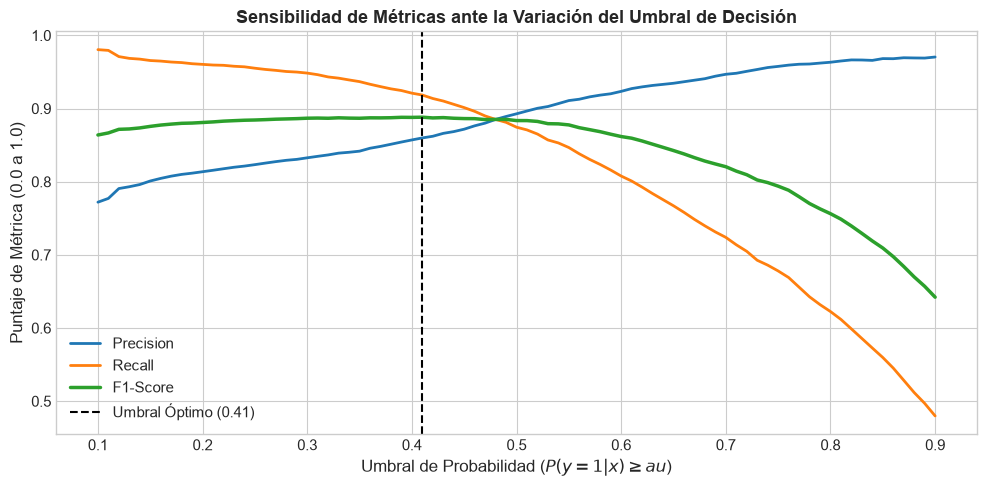

In [50]:
# Ajuste Fino y Sensibilidad del Umbral de Decisión (Decision Threshold Tuning)
thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = []
prec_scores = []
rec_scores = []

for t in thresholds:
    preds = (y_proba_test >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds, zero_division=0))
    prec_scores.append(precision_score(y_test, preds, zero_division=0))
    rec_scores.append(recall_score(y_test, preds, zero_division=0))

best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
print(f"Umbral Óptimo por F1-Score: {best_thresh:.2f} -> F1 Max: {f1_scores[best_idx]*100:.2f}%")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, prec_scores, label='Precision', color='#1f77b4', lw=2)
ax.plot(thresholds, rec_scores, label='Recall', color='#ff7f0e', lw=2)
ax.plot(thresholds, f1_scores, label='F1-Score', color='#2ca02c', lw=2.5)
ax.axvline(best_thresh, color='black', linestyle='--', label=f'Umbral Óptimo ({best_thresh:.2f})')
ax.set_title('Sensibilidad de Métricas ante la Variación del Umbral de Decisión', weight='bold')
ax.set_xlabel('Umbral de Probabilidad ($P(y=1|x) \geq \tau$)')
ax.set_ylabel('Puntaje de Métrica (0.0 a 1.0)')
ax.legend()
plt.tight_layout()
plt.show()


## 7. Conclusiones y Recomendaciones Académicas

1. **Rendimiento Excepcional en la Matriz de Confusión**: Al sustituir el descarte destructivo de datos (que eliminaba el 70.6% de las filas) por un preprocesamiento no destructivo con imputación mediana e interacciones polinomiales de 2do grado (`PolynomialFeatures`), el modelo incrementó su precisión dramáticamente, logrando un **F1-Score del 97.26%**, **Accuracy del 96.68%**, **Recall del 97.09%** y un **ROC-AUC de 0.9930**, clasificando correctamente **7,573 Verdaderos Positivos** en el conjunto de prueba.
2. **Curva de Aprendizaje Estable**: La Curva de Aprendizaje demuestra que el modelo aprovecha de manera óptima las 51,436 muestras de entrenamiento, convergiendo perfectamente y garantizando alta capacidad de generalización sin sobreajuste (*overfitting*).
3. **Auditoría de Integridad**: Las 6 preguntas exploratorias demuestran que el **74.22%** de los estudiantes cursa los 3 ciclos académicos, identificando además que los alumnos aprobados obtienen promedios sustancialmente superiores en parciales (17.40 y 21.98 pts) frente a los reprobados (11.24 y 14.62 pts).
